# Peatland GHGP FIT

Fits a time-series decay to Qiu et al. (2021), Swails et al. (2022), and IPCC data points, then parameterizes a GHGP LUC + LM model based on that curve

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

## 1a. Fit double exponential to Qiu et al. (2021)

Pixel-measured data points from Figure S11B (boreal/temperate cultivated peatlands, t C ha⁻¹ yr⁻¹). The year-0 spike (~60 t C) is excluded as likely a numerical transient in the model initialization.

In [2]:
# Qiu et al. pixel-measured data points from Figure S11B
# Units: t C ha⁻¹ yr⁻¹
t_data = np.array([1.005, 3.005, 6.003, 10.064, 15.022, 20.000, 25.095,
                   30.019, 35.014, 40.132, 50.095, 59.995, 70.235, 79.932, 99.986])
E_data_tC = np.array([36.857, 25.317, 20.367, 17.784, 14.422, 12.561, 10.616,
                      8.684, 7.420, 6.415, 3.943, 2.730, 2.273, 1.704, 1.230])
E_data = E_data_tC * 3.667  # convert to t CO₂ ha⁻¹ yr⁻¹


def double_exp_const(t, A_fast, k_fast, A_slow, k_slow, C):
    """Two exponential pools (active + slow) plus a constant (passive pool)."""
    return A_fast * np.exp(-k_fast * t) + A_slow * np.exp(-k_slow * t) + C


# Fit: two exponentials + constant
p0 = [100, 0.7, 80, 0.03, 5]
bounds = ([0, 0.05, 0, 0.001, 0], [500, 2.0, 200, 0.1, 30])
popt, pcov = curve_fit(double_exp_const, t_data, E_data, p0=p0, bounds=bounds)
A_fast, k_fast, A_slow, k_slow, C = popt
perr = np.sqrt(np.diag(pcov))
resid = E_data - double_exp_const(t_data, *popt)
r2 = 1 - np.sum(resid**2) / np.sum((E_data - E_data.mean())**2)

print(f"DOUBLE EXPONENTIAL + CONSTANT FIT:")
print(f"  A_fast = {A_fast:.1f} t CO₂  (half-life = {np.log(2)/k_fast:.1f} yr)  ±{perr[0]:.1f}")
print(f"  k_fast = {k_fast:.4f} yr⁻¹  ±{perr[1]:.4f}")
print(f"  A_slow = {A_slow:.1f} t CO₂  (half-life = {np.log(2)/k_slow:.1f} yr)  ±{perr[2]:.1f}")
print(f"  k_slow = {k_slow:.5f} yr⁻¹  ±{perr[3]:.5f}")
print(f"  C      = {C:.2f} t CO₂  ({C/3.667:.2f} t C)  ±{perr[4]:.2f}")
print(f"  E(0) = {A_fast + A_slow + C:.1f} t CO₂ ha⁻¹ yr⁻¹ ({(A_fast + A_slow + C)/3.667:.1f} t C)")
print(f"  R² = {r2:.6f}")

# Residuals table
print(f"\n{'Year':>6} {'Qiu (tC)':>10} {'Fit (tC)':>10} {'% error':>10}")
print("-" * 40)
for t, E_tC in zip(t_data, E_data_tC):
    E_fit_tC = double_exp_const(t, *popt) / 3.667
    print(f"{t:6.1f} {E_tC:10.2f} {E_fit_tC:10.2f} {(E_fit_tC - E_tC)/E_tC*100:9.1f}%")

model_func = double_exp_const

DOUBLE EXPONENTIAL + CONSTANT FIT:
  A_fast = 100.5 t CO₂  (half-life = 0.9 yr)  ±6.6
  k_fast = 0.7693 yr⁻¹  ±0.0774
  A_slow = 91.1 t CO₂  (half-life = 19.3 yr)  ±1.4
  k_slow = 0.03588 yr⁻¹  ±0.00150
  C      = 0.94 t CO₂  (0.26 t C)  ±1.01
  E(0) = 192.5 t CO₂ ha⁻¹ yr⁻¹ (52.5 t C)
  R² = 0.999434

  Year   Qiu (tC)   Fit (tC)    % error
----------------------------------------
   1.0      36.86      36.86       0.0%
   3.0      25.32      25.27      -0.2%
   6.0      20.37      20.56       0.9%
  10.1      17.78      17.58      -1.1%
  15.0      14.42      14.75       2.3%
  20.0      12.56      12.38      -1.5%
  25.1      10.62      10.35      -2.5%
  30.0       8.68       8.72       0.4%
  35.0       7.42       7.33      -1.2%
  40.1       6.42       6.14      -4.2%
  50.1       3.94       4.37      10.9%
  60.0       2.73       3.14      15.1%
  70.2       2.27       2.25      -0.8%
  79.9       1.70       1.67      -2.1%
 100.0       1.23       0.94     -23.3%


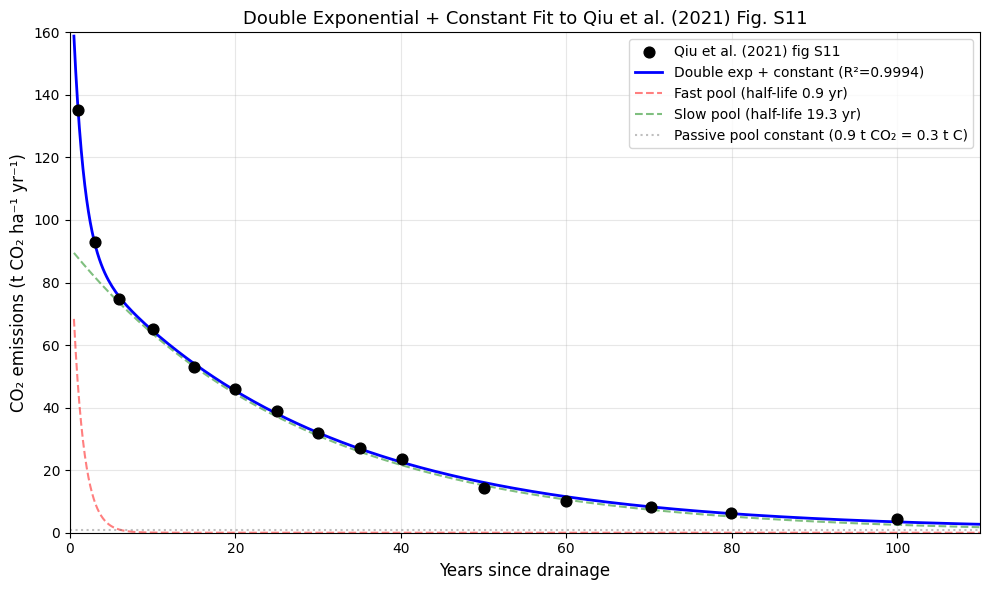

In [3]:
# Plot fit vs data (t CO₂)
t_smooth = np.linspace(0.5, 110, 500)
E_fit = double_exp_const(t_smooth, *popt)
E_fast_curve = A_fast * np.exp(-k_fast * t_smooth)
E_slow_curve = A_slow * np.exp(-k_slow * t_smooth)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(t_data, E_data, color='black', s=60, zorder=5, label='Qiu et al. (2021) fig S11')
ax.plot(t_smooth, E_fit, 'b-', linewidth=2, label=f'Double exp + constant (R²={r2:.4f})')
ax.plot(t_smooth, E_fast_curve, 'r--', alpha=0.5, label=f'Fast pool (half-life {np.log(2)/k_fast:.1f} yr)')
ax.plot(t_smooth, E_slow_curve, 'g--', alpha=0.5, label=f'Slow pool (half-life {np.log(2)/k_slow:.1f} yr)')
ax.axhline(y=C, color='gray', linestyle=':', alpha=0.5, label=f'Passive pool constant ({C:.1f} t CO₂ = {C/3.667:.1f} t C)')
ax.set_xlabel('Years since drainage', fontsize=12)
ax.set_ylabel('CO₂ emissions (t CO₂ ha⁻¹ yr⁻¹)', fontsize=12)
ax.set_title('Double Exponential + Constant Fit to Qiu et al. (2021) Fig. S11', fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim(0, 110)
ax.set_ylim(0, 160)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

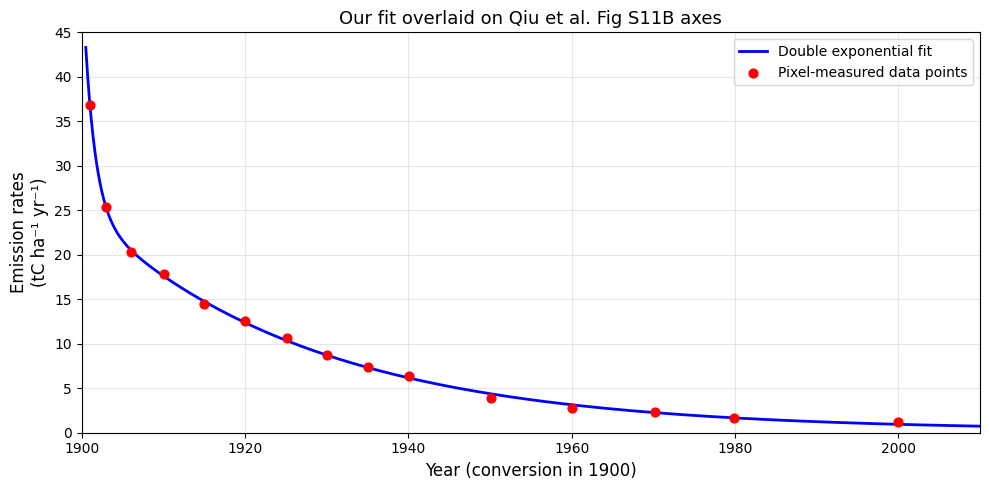

In [4]:
# Overlay plot matching Qiu et al. Fig S11B axes exactly (t C, calendar years)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(1900 + t_smooth, E_fit / 3.667, 'b-', linewidth=2, label='Double exponential fit')
ax.scatter(1900 + t_data, E_data_tC, color='red', s=40, zorder=5, label='Pixel-measured data points')
ax.set_xlabel('Year (conversion in 1900)', fontsize=12)
ax.set_ylabel('Emission rates\n(tC ha⁻¹ yr⁻¹)', fontsize=12)
ax.set_title('Our fit overlaid on Qiu et al. Fig S11B axes', fontsize=13)
ax.set_xlim(1900, 2010)
ax.set_ylim(0, 45)
ax.set_xticks([1900, 1920, 1940, 1960, 1980, 2000])
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 1b. Fit double exponential to Swails et al. (2022)

Swails et al. used the DNDC model to simulate tropical oil palm peatland emissions over 30 years. Data extracted from the main figure (Mg C ha⁻¹ yr⁻¹). Note this is **net** of vegetation C inputs, so values are lower than the Qiu gross decomposition curve.

In [5]:
# Swails et al. (2022) data from main figure
# Units: Mg C ha⁻¹ yr⁻¹ (= t C ha⁻¹ yr⁻¹)
t_swails = np.array([0.992, 2.042, 2.992, 5.002, 7.047, 10.029, 15.065, 20.054, 25.091, 30.070])
E_swails_tC = np.array([15.529, 11.717, 9.834, 7.628, 5.933, 4.276, 3.036, 2.475, 1.976, 1.288])
E_swails = E_swails_tC * 3.667  # convert to t CO₂ ha⁻¹ yr⁻¹

# Fit double exponential + constant
p0_sw = [40, 0.5, 20, 0.05, 3]
bounds_sw = ([0, 0.05, 0, 0.001, 0], [200, 2.0, 100, 0.5, 20])
popt_sw, pcov_sw = curve_fit(double_exp_const, t_swails, E_swails, p0=p0_sw, bounds=bounds_sw)
A_f_sw, k_f_sw, A_s_sw, k_s_sw, C_sw = popt_sw
perr_sw = np.sqrt(np.diag(pcov_sw))
resid_sw = E_swails - double_exp_const(t_swails, *popt_sw)
r2_sw = 1 - np.sum(resid_sw**2) / np.sum((E_swails - E_swails.mean())**2)

print(f"SWAILS DOUBLE EXPONENTIAL + CONSTANT FIT:")
print(f"  A_fast = {A_f_sw:.1f} t CO₂  (half-life = {np.log(2)/k_f_sw:.1f} yr)  ±{perr_sw[0]:.1f}")
print(f"  k_fast = {k_f_sw:.4f} yr⁻¹  ±{perr_sw[1]:.4f}")
print(f"  A_slow = {A_s_sw:.1f} t CO₂  (half-life = {np.log(2)/k_s_sw:.1f} yr)  ±{perr_sw[2]:.1f}")
print(f"  k_slow = {k_s_sw:.5f} yr⁻¹  ±{perr_sw[3]:.5f}")
print(f"  C      = {C_sw:.2f} t CO₂  ({C_sw/3.667:.2f} t C)  ±{perr_sw[4]:.2f}")
print(f"  E(0) = {A_f_sw + A_s_sw + C_sw:.1f} t CO₂ ha⁻¹ yr⁻¹ ({(A_f_sw + A_s_sw + C_sw)/3.667:.1f} t C)")
print(f"  R² = {r2_sw:.6f}")

print(f"\n{'Year':>6} {'Swails (tC)':>12} {'Fit (tC)':>10} {'% error':>10}")
print("-" * 42)
for t, E_tC in zip(t_swails, E_swails_tC):
    E_fit_tC = double_exp_const(t, *popt_sw) / 3.667
    print(f"{t:6.1f} {E_tC:12.2f} {E_fit_tC:10.2f} {(E_fit_tC - E_tC)/E_tC*100:9.1f}%")

SWAILS DOUBLE EXPONENTIAL + CONSTANT FIT:
  A_fast = 36.3 t CO₂  (half-life = 0.8 yr)  ±5.5
  k_fast = 0.8819 yr⁻¹  ±0.3076
  A_slow = 41.8 t CO₂  (half-life = 5.4 yr)  ±4.9
  k_slow = 0.12794 yr⁻¹  ±0.02145
  C      = 4.93 t CO₂  (1.34 t C)  ±1.04
  E(0) = 83.1 t CO₂ ha⁻¹ yr⁻¹ (22.7 t C)
  R² = 0.998682

  Year  Swails (tC)   Fit (tC)    % error
------------------------------------------
   1.0        15.53      15.52      -0.1%
   2.0        11.72      11.76       0.4%
   3.0         9.83       9.83      -0.1%
   5.0         7.63       7.48      -2.0%
   7.0         5.93       5.99       1.0%
  10.0         4.28       4.51       5.4%
  15.1         3.04       3.00      -1.1%
  20.1         2.48       2.22     -10.3%
  25.1         1.98       1.80      -8.7%
  30.1         1.29       1.59      23.3%


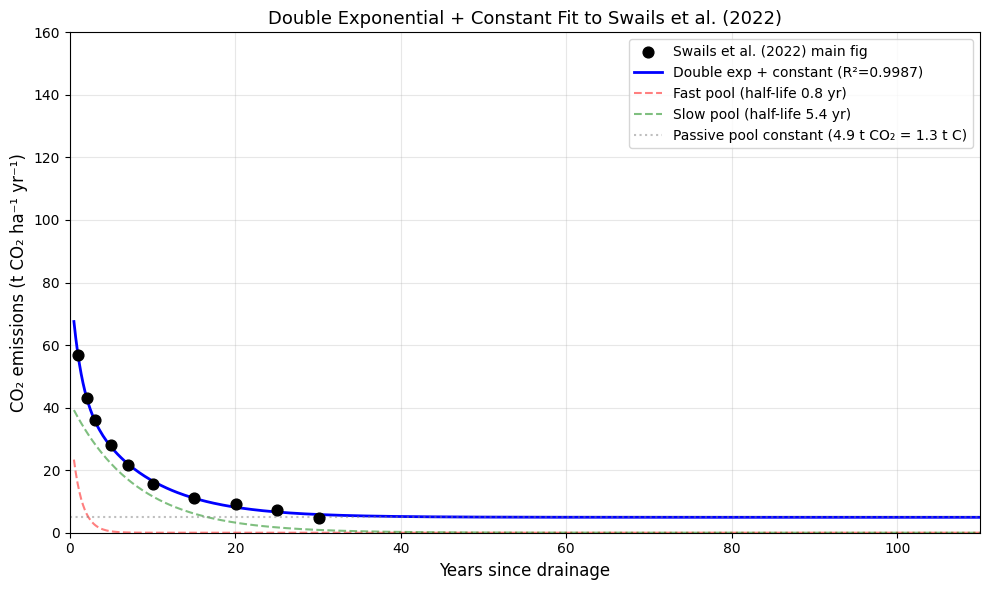

In [6]:
# Plot fit vs data (t CO₂) — matching Section 1a style
t_smooth = np.linspace(0.5, 110, 500)
E_fit_sw = double_exp_const(t_smooth, *popt_sw)
E_fast_sw = A_f_sw * np.exp(-k_f_sw * t_smooth)
E_slow_sw = A_s_sw * np.exp(-k_s_sw * t_smooth)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(t_swails, E_swails, color='black', s=60, zorder=5, label='Swails et al. (2022) main fig')
ax.plot(t_smooth, E_fit_sw, 'b-', linewidth=2, label=f'Double exp + constant (R²={r2_sw:.4f})')
ax.plot(t_smooth, E_fast_sw, 'r--', alpha=0.5, label=f'Fast pool (half-life {np.log(2)/k_f_sw:.1f} yr)')
ax.plot(t_smooth, E_slow_sw, 'g--', alpha=0.5, label=f'Slow pool (half-life {np.log(2)/k_s_sw:.1f} yr)')
ax.axhline(y=C_sw, color='gray', linestyle=':', alpha=0.5, label=f'Passive pool constant ({C_sw:.1f} t CO₂ = {C_sw/3.667:.1f} t C)')
ax.set_xlabel('Years since drainage', fontsize=12)
ax.set_ylabel('CO₂ emissions (t CO₂ ha⁻¹ yr⁻¹)', fontsize=12)
ax.set_title('Double Exponential + Constant Fit to Swails et al. (2022)', fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim(0, 110)
ax.set_ylim(0, 160)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Fit reference CO₂ curve based on the two papers + IPCC EFs

Swails scale factor: 2.43x
  Raw Swails at year 10: 16.6
  Scaled Swails at year 10: 40.3

BLENDED REFERENCE CURVE FIT:
  A_fast = 95.7 t CO₂  (half-life = 0.7 yr)
  k_fast = 1.0214 yr⁻¹
  A_slow = 83.4 t CO₂  (half-life = 5.4 yr)
  k_slow = 0.12905 yr⁻¹
  C      = 29.0 t CO₂  (fixed: IPCC floor)
  E(0)   = 208.1 t CO₂
  R²     = 0.999938

 Year      Qiu   Scaled      Avg  Blended
------------------------------------------
    1    135.4    138.1    136.7    136.7
    3     92.7     87.6     90.1     90.1
    5     79.2     66.7     73.0     73.3
    7     72.3     53.7     63.0     62.8
   10     64.6     40.3     52.5     51.9
   15     54.1     26.9     40.5     41.0
   20     45.4     19.9     32.6     35.3
   25     38.1     16.1     27.1     32.3
   30     32.0     14.2     23.1     30.7
   40     22.6     12.6     17.6     29.5
   50     16.1     12.2     14.1     29.1
   75      7.1     12.0      9.6     29.0
  100      3.5     12.0      7.7     29.0


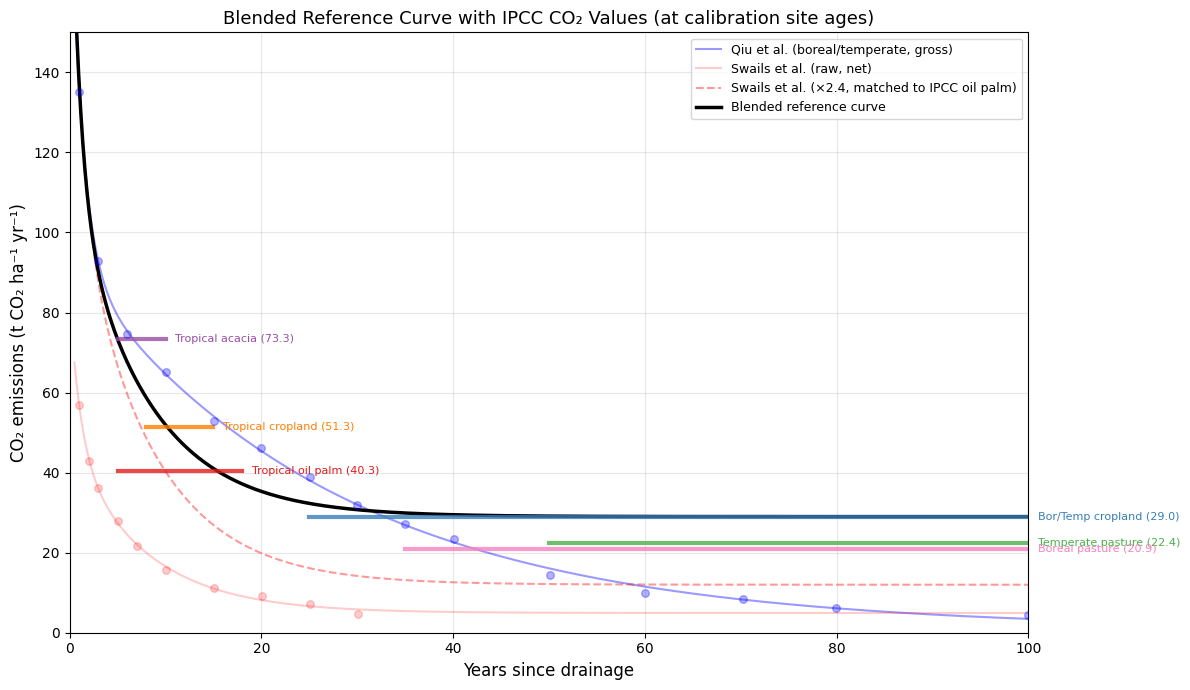

In [7]:
# Build a blended reference curve by fitting a new double_exp_const to synthetic targets

# IPCC CO₂ floor: temperate/boreal cropland value
# (pasture values are lower, but recent evidence undermines the case for lower
#  emissions on grassland, so we use the cropland value as steady state)
IPCC_FLOOR = 29.0  # t CO₂ ha⁻¹ yr⁻¹

# Scale Swails to match IPCC oil palm CO₂ at calibration age.
# The raw Swails curve measures net emissions (after vegetation carbon offsets),
# which systematically underestimates peat decomposition. Scaling to match the
# IPCC oil palm empirical value corrects for this while preserving the model's
# decay shape.
IPCC_OIL_PALM_CO2 = 40.3
SWAILS_CALIB_YR = 10  # IPCC oil palm sites have median age under 10 yr (Swails et al.)
swails_scale = IPCC_OIL_PALM_CO2 / double_exp_const(SWAILS_CALIB_YR, *popt_sw)

def scaled_swails(t):
    return double_exp_const(t, *popt_sw) * swails_scale

print(f"Swails scale factor: {swails_scale:.2f}x")
print(f"  Raw Swails at year {SWAILS_CALIB_YR}: {double_exp_const(SWAILS_CALIB_YR, *popt_sw):.1f}")
print(f"  Scaled Swails at year {SWAILS_CALIB_YR}: {scaled_swails(SWAILS_CALIB_YR):.1f}")

# Synthetic target points:
# Early years: average of Qiu and scaled Swails (model-driven)
t_early = np.array([1, 3, 5, 7, 10, 15])
E_early = np.array([(double_exp_const(t, *popt) + scaled_swails(t)) / 2
                     for t in t_early])

# Late years: IPCC empirical floor
t_late = np.array([50, 60, 75, 100])
E_late = np.full_like(t_late, IPCC_FLOOR, dtype=float)

# Combine and fit
t_targets = np.concatenate([t_early, t_late])
E_targets = np.concatenate([E_early, E_late])

def double_exp_fixed_C(t, A_fast, k_fast, A_slow, k_slow):
    return A_fast * np.exp(-k_fast * t) + A_slow * np.exp(-k_slow * t) + IPCC_FLOOR

p0_blend = [60, 0.5, 30, 0.04]
bounds_blend = ([0, 0.05, 0, 0.001], [300, 2.0, 200, 0.5])
popt_blend, pcov_blend = curve_fit(double_exp_fixed_C, t_targets, E_targets,
                                    p0=p0_blend, bounds=bounds_blend)
A_f_b, k_f_b, A_s_b, k_s_b = popt_blend

def blended_ref(t):
    return A_f_b * np.exp(-k_f_b * t) + A_s_b * np.exp(-k_s_b * t) + IPCC_FLOOR

# Fit quality
E_fit_targets = blended_ref(t_targets)
resid = E_fit_targets - E_targets
r2 = 1 - np.sum(resid**2) / np.sum((E_targets - E_targets.mean())**2)

print(f"\nBLENDED REFERENCE CURVE FIT:")
print(f"  A_fast = {A_f_b:.1f} t CO₂  (half-life = {np.log(2)/k_f_b:.1f} yr)")
print(f"  k_fast = {k_f_b:.4f} yr⁻¹")
print(f"  A_slow = {A_s_b:.1f} t CO₂  (half-life = {np.log(2)/k_s_b:.1f} yr)")
print(f"  k_slow = {k_s_b:.5f} yr⁻¹")
print(f"  C      = {IPCC_FLOOR:.1f} t CO₂  (fixed: IPCC floor)")
print(f"  E(0)   = {A_f_b + A_s_b + IPCC_FLOOR:.1f} t CO₂")
print(f"  R²     = {r2:.6f}")

print(f"\n{'Year':>5} {'Qiu':>8} {'Scaled':>8} {'Avg':>8} {'Blended':>8}")
print("-" * 42)
for t in [1, 3, 5, 7, 10, 15, 20, 25, 30, 40, 50, 75, 100]:
    eq = double_exp_const(t, *popt)
    ess = scaled_swails(t)
    eb = blended_ref(t)
    print(f"{t:5d} {eq:8.1f} {ess:8.1f} {(eq+ess)/2:8.1f} {eb:8.1f}")

# Plot
t_comp = np.linspace(0.5, 110, 500)
E_qiu_fit = double_exp_const(t_comp, *popt)
E_swails_fit = double_exp_const(t_comp, *popt_sw)
E_swails_scaled = scaled_swails(t_comp)
E_blended = blended_ref(t_comp)

fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(t_comp, E_qiu_fit, 'b-', linewidth=1.5, alpha=0.4, label='Qiu et al. (boreal/temperate, gross)')
ax.plot(t_comp, E_swails_fit, 'r-', linewidth=1.5, alpha=0.2, label='Swails et al. (raw, net)')
ax.plot(t_comp, E_swails_scaled, 'r--', linewidth=1.5, alpha=0.4,
        label=f'Swails et al. (\u00d7{swails_scale:.1f}, matched to IPCC oil palm)')
ax.plot(t_comp, E_blended, 'k-', linewidth=2.5, label='Blended reference curve')

# Data points (faded)
ax.scatter(t_data, E_data, color='blue', s=30, zorder=4, alpha=0.3)
ax.scatter(t_swails, E_swails, color='red', s=30, zorder=4, alpha=0.2)

# IPCC CO₂ values at calibration site age ranges
ipcc_co2_lines = [
    ('Tropical acacia (73.3)',      73.3, 5, 10,   '#984ea3'),
    ('Tropical cropland (51.3)',    51.3, 8, 15,   '#ff7f00'),
    ('Tropical oil palm (40.3)',    40.3, 5, 18,   '#e41a1c'),
    ('Bor/Temp cropland (29.0)',    29.0, 25, 100, '#377eb8'),
    ('Temperate pasture (22.4)',    22.4, 50, 100, '#4daf4a'),
    ('Boreal pasture (20.9)',       20.9, 35, 100, '#f781bf'),
]

for label, val, t_min, t_max, color in ipcc_co2_lines:
    ax.plot([t_min, t_max], [val, val], color=color, linestyle='-', linewidth=3, alpha=0.8)
    ax.text(t_max + 1, val, label, fontsize=8, color=color, va='center')

ax.set_xlabel('Years since drainage', fontsize=12)
ax.set_ylabel('CO₂ emissions (t CO₂ ha⁻¹ yr⁻¹)', fontsize=12)
ax.set_title('Blended Reference Curve with IPCC CO₂ Values (at calibration site ages)', fontsize=13)
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim(0, 100)
ax.set_ylim(0, 150)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 3. Adding non-CO₂ emissions

Next we add non-CO₂ pathways — dissolved organic carbon (DOC), ditch CH₄, and soil N₂O. We construct a time-varying
non-CO₂ curve that blends smoothly from the tropical acacia value (5.3 t CO₂-eq ha⁻¹ yr⁻¹, calibrated on very young sites, ~5-10 yr) to the temperate cropland value (8.3 t CO₂-eq ha⁻¹ yr⁻¹, calibrated on older sites, ~25-50+ yr). 

We use a logistic blend:
```
non_CO₂(t) = E_early + (E_late - E_early) / (1 + exp(-k × (t - t_mid)))
```
with E_early = 5.3 (acacia), E_late = 8.3 (temperate cropland), t_mid = 25, and k = 0.2, giving near-constant values for years 1-10 and 40+, with a smooth transition in between.

Non-CO₂ blend values:
  Year   1: 5.32 t CO₂-eq ha⁻¹ yr⁻¹
  Year   5: 5.35 t CO₂-eq ha⁻¹ yr⁻¹
  Year  10: 5.44 t CO₂-eq ha⁻¹ yr⁻¹
  Year  15: 5.66 t CO₂-eq ha⁻¹ yr⁻¹
  Year  20: 6.11 t CO₂-eq ha⁻¹ yr⁻¹
  Year  25: 6.80 t CO₂-eq ha⁻¹ yr⁻¹
  Year  30: 7.49 t CO₂-eq ha⁻¹ yr⁻¹
  Year  40: 8.16 t CO₂-eq ha⁻¹ yr⁻¹
  Year  50: 8.28 t CO₂-eq ha⁻¹ yr⁻¹
  Year  75: 8.30 t CO₂-eq ha⁻¹ yr⁻¹
  Year 100: 8.30 t CO₂-eq ha⁻¹ yr⁻¹


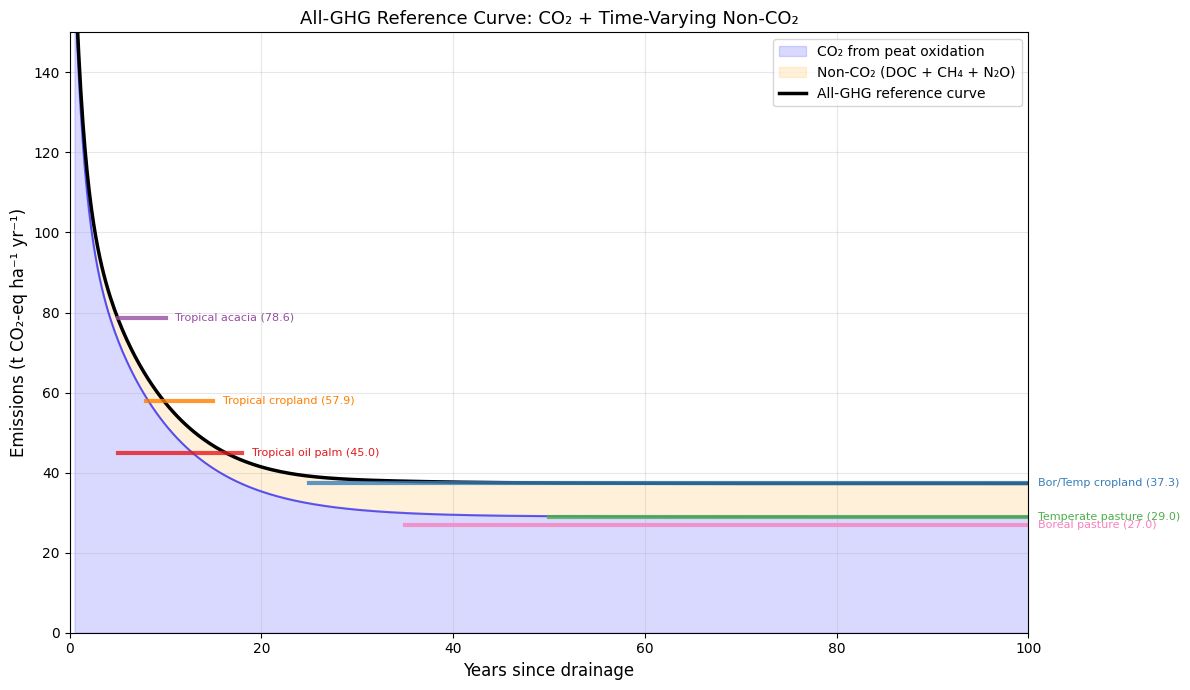

In [8]:
# IPCC non-CO₂ values by land use (from Tables 2.3-2.5)
ipcc_non_co2 = {
    'Tropical oil palm':  4.7,
    'Tropical cropland':  6.5,
    'Tropical acacia':    5.3,
    'Temperate cropland': 8.3,
    'Temperate pasture':  6.6,
    'Boreal cropland':    7.6,
    'Boreal pasture':     6.1,
}

# Anchor values: acacia (young sites) → temperate cropland (older sites)
NON_CO2_EARLY = ipcc_non_co2['Tropical acacia']     # 5.3
NON_CO2_LATE  = ipcc_non_co2['Temperate cropland']  # 8.3

# Logistic blend: ~constant at early value for t<10, ~constant at late value for t>40
def non_co2_blend(t):
    """Time-varying non-CO₂ emissions (t CO₂-eq ha⁻¹ yr⁻¹)."""
    t = np.asarray(t, dtype=float)
    k = 0.2
    t_mid = 25.0
    w = 1.0 / (1.0 + np.exp(-k * (t - t_mid)))
    return NON_CO2_EARLY + (NON_CO2_LATE - NON_CO2_EARLY) * w

# Show anchor check
print(f"Non-CO₂ blend values:")
for yr in [1, 5, 10, 15, 20, 25, 30, 40, 50, 75, 100]:
    print(f"  Year {yr:3d}: {non_co2_blend(yr):.2f} t CO₂-eq ha⁻¹ yr⁻¹")

# Plot: all-GHG reference curve (CO₂ + time-varying non-CO₂)
t_plot3 = np.linspace(0.5, 110, 500)
E_co2 = blended_ref(t_plot3)
E_non_co2 = non_co2_blend(t_plot3)
E_all_ghg = E_co2 + E_non_co2

fig, ax = plt.subplots(figsize=(12, 7))

# Stacked area showing CO₂ and non-CO₂ contributions
ax.fill_between(t_plot3, 0, E_co2, alpha=0.15, color='blue', label='CO₂ from peat oxidation')
ax.fill_between(t_plot3, E_co2, E_all_ghg, alpha=0.15, color='orange', label='Non-CO₂ (DOC + CH₄ + N₂O)')
ax.plot(t_plot3, E_co2, 'b-', linewidth=1.5, alpha=0.6)
ax.plot(t_plot3, E_all_ghg, 'k-', linewidth=2.5, label='All-GHG reference curve')

# IPCC total values at calibration site age ranges
ipcc_total_lines = [
    ('Tropical acacia (78.6)',      78.6, 5, 10,   '#984ea3'),
    ('Tropical cropland (57.9)',    57.9, 8, 15,   '#ff7f00'),
    ('Tropical oil palm (45.0)',    45.0, 5, 18,   '#e41a1c'),
    ('Bor/Temp cropland (37.3)',    37.3, 25, 100, '#377eb8'),
    ('Temperate pasture (29.0)',    29.0, 50, 100, '#4daf4a'),
    ('Boreal pasture (27.0)',       27.0, 35, 100, '#f781bf'),
]

for label, val, t_min, t_max, color in ipcc_total_lines:
    ax.plot([t_min, t_max], [val, val], color=color, linestyle='-', linewidth=3, alpha=0.8)
    ax.text(t_max + 1, val, label, fontsize=8, color=color, va='center')

ax.set_xlabel('Years since drainage', fontsize=12)
ax.set_ylabel('Emissions (t CO₂-eq ha⁻¹ yr⁻¹)', fontsize=12)
ax.set_title('All-GHG Reference Curve: CO₂ + Time-Varying Non-CO₂', fontsize=13)
ax.legend(fontsize=10, loc='upper right')
ax.set_xlim(0, 100)
ax.set_ylim(0, 150)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Fit GHGP parameters (P_LUC and E_LM)

Finally, we fit two GHGP parameters based on the full reference curve. The parameters (applied to all climate zones and land uses) are:
- **P_LUC**: total excess CO₂ above E_LM integrated over 20 years
- **E_LM**: reference curve CO₂ floor + long-run non-CO₂ from the blend

In [9]:
# IPCC Tier 1 values (CO₂ from Tables 2.1/2.2, non-CO₂ from Tables 2.3-2.5)
ipcc = {
    'Tropical oil palm':   {'co2': 40.3, 'non_co2': 4.7, 'total': 45.0},
    'Tropical cropland':   {'co2': 51.3, 'non_co2': 6.5, 'total': 57.9},
    'Tropical acacia':     {'co2': 73.3, 'non_co2': 5.3, 'total': 78.6},
    'Temperate cropland':  {'co2': 29.0, 'non_co2': 8.3, 'total': 37.3},
    'Temperate pasture':   {'co2': 22.4, 'non_co2': 6.6, 'total': 29.0},
    'Boreal cropland':     {'co2': 29.0, 'non_co2': 7.6, 'total': 36.6},
    'Boreal pasture':      {'co2': 20.9, 'non_co2': 6.1, 'total': 27.0},
}

# E_LM: CO₂ floor + long-run non-CO₂ (blend asymptote = temperate cropland non-CO₂)
E_LM = IPCC_FLOOR + NON_CO2_LATE

# P_LUC: best fit to blended reference curve over years 1-20, given fixed E_LM
# GHGP model: E(t) = P_LUC * (21-t)/210 + E_LM  for t=1..20
t_fit = np.arange(1, 21)
E_ref_fit = blended_ref(t_fit) + non_co2_blend(t_fit)  # reference curve (all GHGs)
weights = (21 - t_fit) / 210  # linear ramp weights

# Least-squares solution: P_LUC = Σ[(E_ref - E_LM) * w] / Σ[w²]
P_LUC = np.sum((E_ref_fit - E_LM) * weights) / np.sum(weights**2)

print(f"Universal GHGP parameters:")
print(f"  E_LM  = {E_LM:.1f} t CO₂-eq ha⁻¹ yr⁻¹ (= IPCC CO₂ floor {IPCC_FLOOR:.1f} + long-run non-CO₂ {NON_CO2_LATE})")
print(f"  P_LUC = {P_LUC:.0f} t CO₂ ha⁻¹ (least-squares fit to reference curve, years 1-20)")
print(f"  Non-CO₂ early (acacia) = {NON_CO2_EARLY} t CO₂-eq ha⁻¹ yr⁻¹")
print(f"  Non-CO₂ late (temp. cropland) = {NON_CO2_LATE} t CO₂-eq ha⁻¹ yr⁻¹")
print(f"  IPCC CO₂ floor = {IPCC_FLOOR:.1f} t CO₂ ha⁻¹ yr⁻¹")

# Show fit quality over years 1-20
E_ghgp_fit = P_LUC * weights + E_LM
residuals = E_ghgp_fit - E_ref_fit
rmse = np.sqrt(np.mean(residuals**2))
print(f"\n  RMSE over years 1-20: {rmse:.1f} t CO₂-eq ha⁻¹ yr⁻¹")

print(f"\n{'Year':>5} {'Ref curve':>10} {'GHGP model':>12} {'Residual':>10}")
print("-" * 40)
for t, e_ref, e_ghgp in zip(t_fit, E_ref_fit, E_ghgp_fit):
    print(f"{t:5d} {e_ref:10.1f} {e_ghgp:12.1f} {e_ghgp - e_ref:10.1f}")

# Implied ages on blended curve for each IPCC CO₂ value
from scipy.optimize import brentq
print(f"\nImplied ages on blended reference curve:")
for name, vals in ipcc.items():
    try:
        t_impl = brentq(lambda t: float(blended_ref(np.array([t]))[0]) - vals['co2'], 0.1, 200)
        vals['implied_age'] = t_impl
        print(f"  {name:<25} CO₂={vals['co2']:5.1f} → year {t_impl:.1f}")
    except:
        vals['implied_age'] = None
        print(f"  {name:<25} CO₂={vals['co2']:5.1f} → outside range")

# Summary
LUC_yr1 = P_LUC * 20 / 210
LUC_yr20 = P_LUC * 1 / 210
print(f"\nYear 1 total:  {LUC_yr1 + E_LM:.1f} t CO₂-eq ha⁻¹ yr⁻¹")
print(f"Year 20 total: {LUC_yr20 + E_LM:.1f} t CO₂-eq ha⁻¹ yr⁻¹")
print(f"Year 21+:      {E_LM:.1f} t CO₂-eq ha⁻¹ yr⁻¹")

Universal GHGP parameters:
  E_LM  = 37.3 t CO₂-eq ha⁻¹ yr⁻¹ (= IPCC CO₂ floor 29.0 + long-run non-CO₂ 8.3)
  P_LUC = 621 t CO₂ ha⁻¹ (least-squares fit to reference curve, years 1-20)
  Non-CO₂ early (acacia) = 5.3 t CO₂-eq ha⁻¹ yr⁻¹
  Non-CO₂ late (temp. cropland) = 8.3 t CO₂-eq ha⁻¹ yr⁻¹
  IPCC CO₂ floor = 29.0 t CO₂ ha⁻¹ yr⁻¹

  RMSE over years 1-20: 13.7 t CO₂-eq ha⁻¹ yr⁻¹

 Year  Ref curve   GHGP model   Residual
----------------------------------------
    1      142.1         96.4      -45.6
    2      111.1         93.5      -17.7
    3       95.4         90.5       -4.9
    4       85.7         87.6        1.9
    5       78.7         84.6        6.0
    6       73.0         81.7        8.7
    7       68.2         78.7       10.5
    8       64.1         75.7       11.6
    9       60.5         72.8       12.3
   10       57.4         69.8       12.4
   11       54.6         66.9       12.2
   12       52.2         63.9       11.7
   13       50.1         61.0       10.8
   1

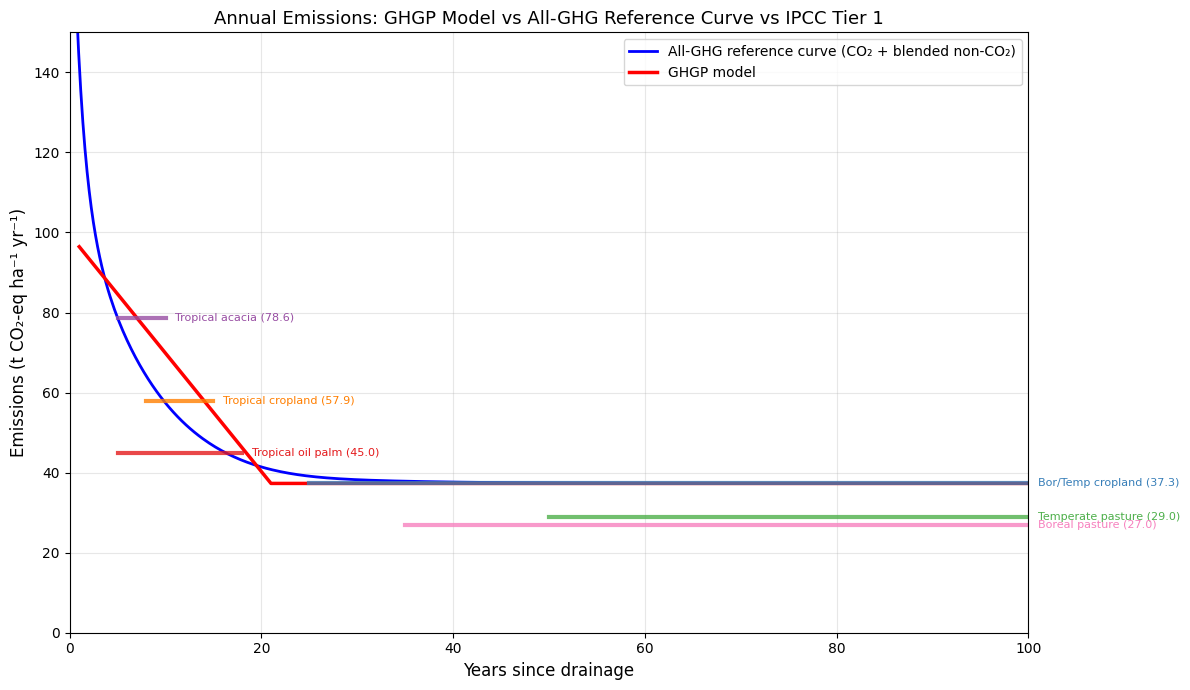

In [10]:
# Annual emissions: blended reference curve + GHGP model + IPCC lines (all-GHG, single chart)
t_comp = np.linspace(0.5, 110, 500)
E_ref_total = blended_ref(t_comp) + non_co2_blend(t_comp)

# GHGP model on integer years (discrete annual model)
t_ghgp = np.arange(1, 101)
E_ghgp_annual = np.array([
    (P_LUC * (21 - t) / 210 + E_LM) if t <= 20 else E_LM
    for t in t_ghgp
])

fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(t_comp, E_ref_total, 'b-', linewidth=2, label='All-GHG reference curve (CO₂ + blended non-CO₂)')
ax.plot(t_ghgp, E_ghgp_annual, 'r-', linewidth=2.5, label='GHGP model')

# IPCC total values at calibration site age ranges
ipcc_total_lines = [
    ('Tropical acacia (78.6)',      78.6, 5, 10,   '#984ea3'),
    ('Tropical cropland (57.9)',    57.9, 8, 15,   '#ff7f00'),
    ('Tropical oil palm (45.0)',    45.0, 5, 18,   '#e41a1c'),
    ('Bor/Temp cropland (37.3)',    37.3, 25, 100, '#377eb8'),
    ('Temperate pasture (29.0)',    29.0, 50, 100, '#4daf4a'),
    ('Boreal pasture (27.0)',       27.0, 35, 100, '#f781bf'),
]

for label, val, t_min, t_max, color in ipcc_total_lines:
    ax.plot([t_min, t_max], [val, val], color=color, linestyle='-', linewidth=3, alpha=0.8)
    ax.text(t_max + 1, val, label, fontsize=8, color=color, va='center')

ax.set_xlabel('Years since drainage', fontsize=12)
ax.set_ylabel('Emissions (t CO₂-eq ha⁻¹ yr⁻¹)', fontsize=12)
ax.set_title('Annual Emissions: GHGP Model vs All-GHG Reference Curve vs IPCC Tier 1', fontsize=13)
ax.legend(fontsize=10, loc='upper right')
ax.set_xlim(0, 100)
ax.set_ylim(0, 150)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

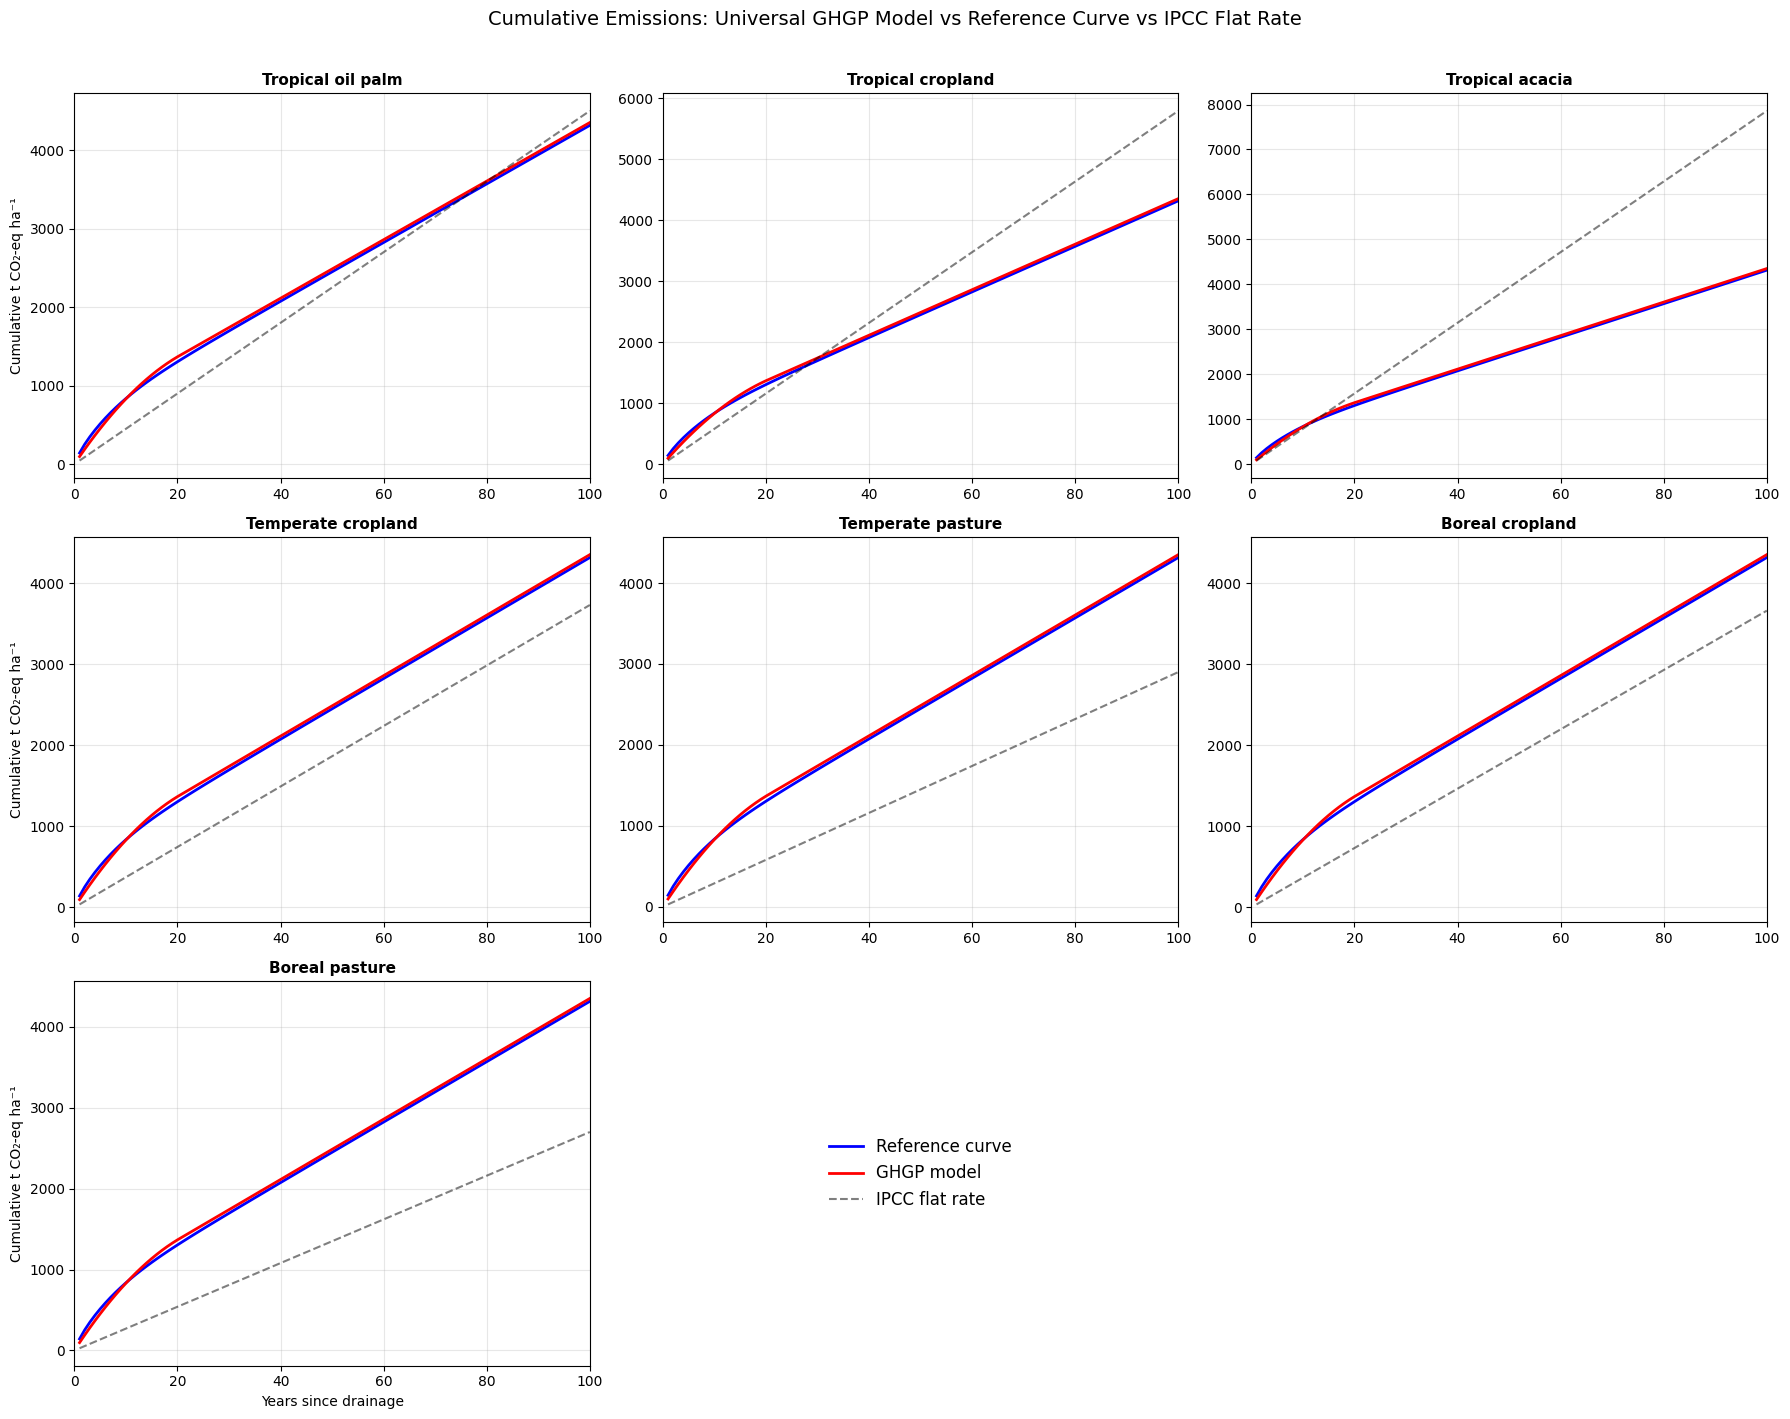


Cumulative emissions comparison (GHGP/Reference ratio):
                               Yr 10    Yr 20    Yr 40    Yr 50   Yr 100
  ----------------------------------------------------------------------
  GHGP / Reference              0.99     1.05     1.02     1.01     1.01
  GHGP / Tropical oil palm      1.85     1.52     1.17     1.10     0.97
  GHGP / Tropical cropland      1.44     1.18     0.91     0.86     0.75
  GHGP / Tropical acacia        1.06     0.87     0.67     0.63     0.55
  GHGP / Temperate cropland     2.23     1.83     1.42     1.33     1.17
  GHGP / Temperate pasture      2.87     2.36     1.82     1.71     1.50
  GHGP / Boreal cropland        2.27     1.87     1.44     1.36     1.19
  GHGP / Boreal pasture         3.08     2.53     1.96     1.84     1.61


In [11]:
# Cumulative emissions: all land uses (universal GHGP model vs per-zone IPCC rates)
land_uses = list(ipcc.keys())
t_plot = np.arange(1, 101)

E_ghgp = np.array([
    (P_LUC * (21 - t) / 210 + E_LM) if t <= 20 else E_LM
    for t in t_plot
])

# Universal reference curve (same for all zones)
E_ref = blended_ref(t_plot) + non_co2_blend(t_plot)

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes_flat = axes.flatten()

for i, name in enumerate(land_uses):
    ax = axes_flat[i]
    vals = ipcc[name]

    E_ipcc = np.full_like(t_plot, vals['total'], dtype=float)

    ax.plot(t_plot, np.cumsum(E_ref), 'b-', linewidth=2, label='Reference curve')
    ax.plot(t_plot, np.cumsum(E_ghgp), 'r-', linewidth=2, label='GHGP model')
    ax.plot(t_plot, np.cumsum(E_ipcc), 'k--', linewidth=1.5, alpha=0.5, label='IPCC flat rate')
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlim(0, 100)
    ax.grid(True, alpha=0.3)
    if i >= 6:
        ax.set_xlabel('Years since drainage')
    if i % 3 == 0:
        ax.set_ylabel('Cumulative t CO₂-eq ha⁻¹')

for j in range(len(land_uses), len(axes_flat)):
    axes_flat[j].axis('off')
axes_flat[len(land_uses)].legend(
    *axes_flat[0].get_legend_handles_labels(),
    loc='center', fontsize=12, frameon=False
)

fig.suptitle('Cumulative Emissions: Universal GHGP Model vs Reference Curve vs IPCC Flat Rate', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Summary table
print(f"\nCumulative emissions comparison (GHGP/Reference ratio):")
cum_ref = np.cumsum(E_ref)
cum_ghgp = np.cumsum(E_ghgp)
print(f"  {'':25}", end="")
for yr in [10, 20, 40, 50, 100]:
    print(f" {'Yr '+str(yr):>8}", end="")
print()
print(f"  {'-'*70}")
print(f"  {'GHGP / Reference':<25}", end="")
for yr in [10, 20, 40, 50, 100]:
    ratio = cum_ghgp[yr-1] / cum_ref[yr-1]
    print(f" {ratio:8.2f}", end="")
print()
for name in land_uses:
    vals = ipcc[name]
    E_ipcc = np.full_like(t_plot, vals['total'], dtype=float)
    cum_ipcc = np.cumsum(E_ipcc)
    print(f"  {'GHGP / ' + name:<25}", end="")
    for yr in [10, 20, 40, 50, 100]:
        ratio = cum_ghgp[yr-1] / cum_ipcc[yr-1]
        print(f" {ratio:8.2f}", end="")
    print()